<center>
    <img src="https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/Logos/organization_logo/organization_logo.png" width="300" alt="cognitiveclass.ai logo">
</center>


#### Import the required libraries we need for the lab.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import levene, ttest_ind, f_oneway, pearsonr

#### Read the dataset in the csv file from the URL


In [ ]:
boston_df=pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv')

#### Add your code below following the instructions given in the course to complete the peer graded assignment


In [ ]:
print("="*50)
print("DATA BOSTON HOUSING")
print("="*50)
print(f"Ukuran dataset: {boston_df.shape}")
print("\n5 baris pertama data:")
print(boston_df.head())


DATA BOSTON HOUSING
Ukuran dataset: (506, 14)

5 baris pertama data:
   Unnamed: 0     CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  \
0           0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0   
1           1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0   
2           2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0   
3           3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0   
4           4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0   

     TAX  PTRATIO  LSTAT  MEDV  
0  296.0     15.3   4.98  24.0  
1  242.0     17.8   9.14  21.6  
2  242.0     17.8   4.03  34.7  
3  222.0     18.7   2.94  33.4  
4  222.0     18.7   5.33  36.2  


In [ ]:
print("\n" + "="*50)
print("INFORMASI DATASET")
print("="*50)

# Informasi dataset
print("\nInformasi dataset:")
print(boston_df.info())


INFORMASI DATASET

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   CRIM        506 non-null    float64
 2   ZN          506 non-null    float64
 3   INDUS       506 non-null    float64
 4   CHAS        506 non-null    float64
 5   NOX         506 non-null    float64
 6   RM          506 non-null    float64
 7   AGE         506 non-null    float64
 8   DIS         506 non-null    float64
 9   RAD         506 non-null    float64
 10  TAX         506 non-null    float64
 11  PTRATIO     506 non-null    float64
 12  LSTAT       506 non-null    float64
 13  MEDV        506 non-null    float64
dtypes: float64(13), int64(1)
memory usage: 55.5 KB
None


In [ ]:
# Statistik deskriptif
print("\nStatistik deskriptif:")
print(boston_df.describe())

# Cek missing values
print("\nCek missing values:")
print(boston_df.isnull().sum())

# Cek duplikasi
print(f"\nJumlah data duplikat: {boston_df.duplicated().sum()}")

# Tipe data setiap kolom
print("\nTipe data setiap kolom:")
print(boston_df.dtypes)



Statistik deskriptif:
       Unnamed: 0        CRIM          ZN       INDUS        CHAS         NOX  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean   252.500000    3.613524   11.363636   11.136779    0.069170    0.554695   
std    146.213884    8.601545   23.322453    6.860353    0.253994    0.115878   
min      0.000000    0.006320    0.000000    0.460000    0.000000    0.385000   
25%    126.250000    0.082045    0.000000    5.190000    0.000000    0.449000   
50%    252.500000    0.256510    0.000000    9.690000    0.000000    0.538000   
75%    378.750000    3.677083   12.500000   18.100000    0.000000    0.624000   
max    505.000000   88.976200  100.000000   27.740000    1.000000    0.871000   

               RM         AGE         DIS         RAD         TAX     PTRATIO  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     6.284634   68.574901    3.795043    9.549407  408.237154   18.455534   
std 


VISUALISASI DISTRIBUSI DATA


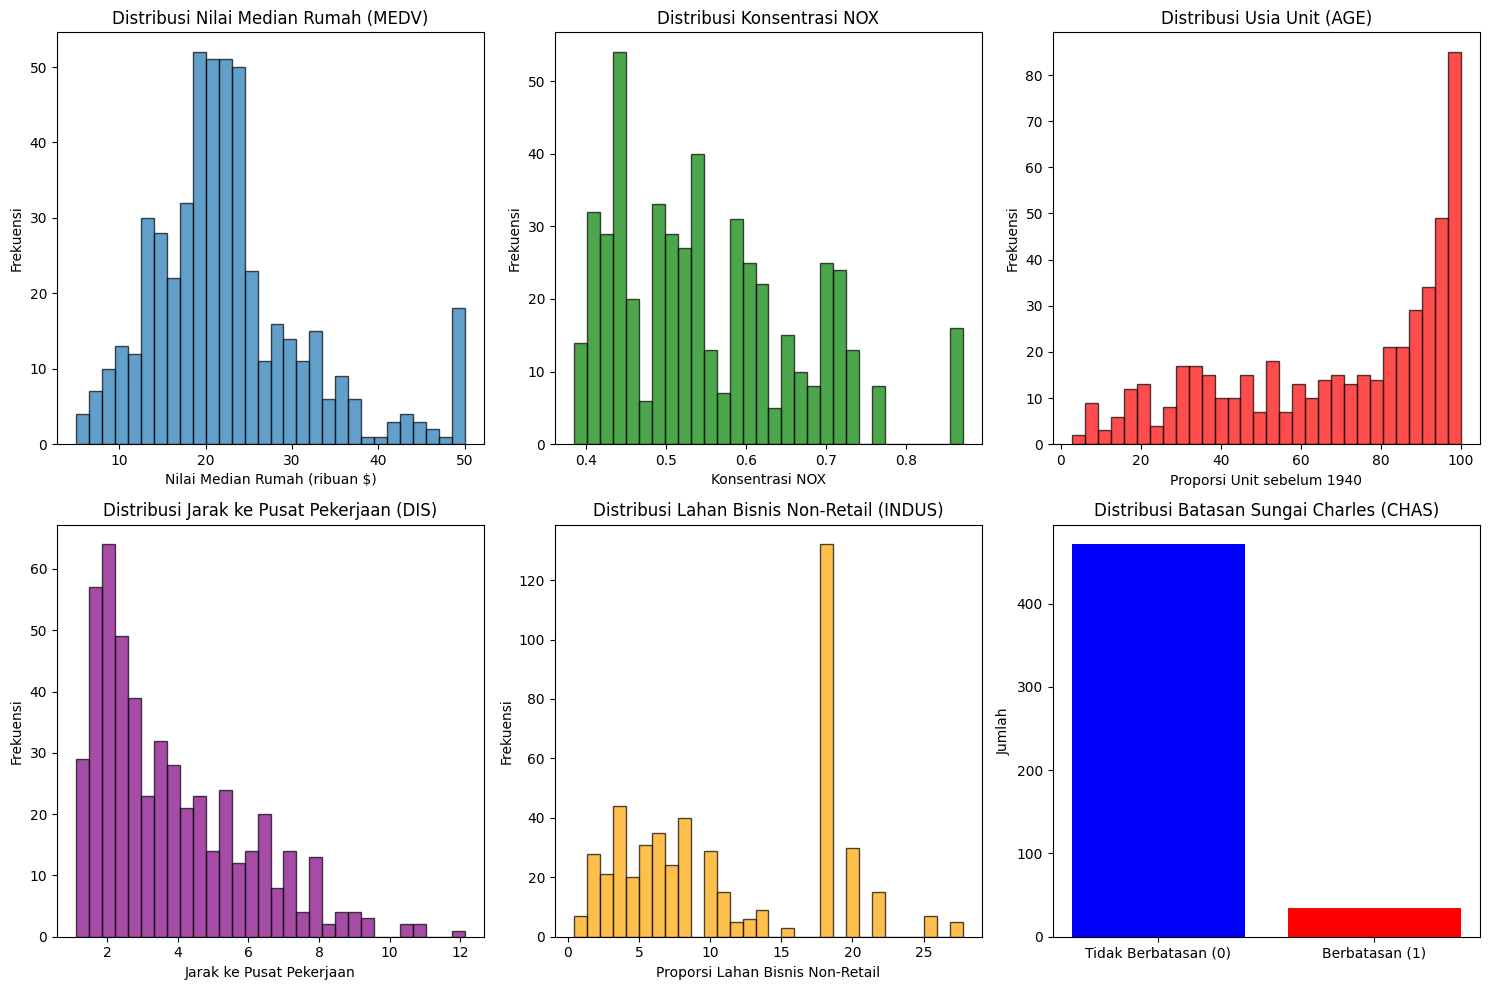

In [ ]:
print("\n" + "="*50)
print("VISUALISASI DISTRIBUSI DATA")
print("="*50)

# Membuat figure dengan subplot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Distribusi MEDV (Nilai median rumah)
axes[0,0].hist(boston_df['MEDV'], bins=30, edgecolor='black', alpha=0.7)
axes[0,0].set_title('Distribusi Nilai Median Rumah (MEDV)')
axes[0,0].set_xlabel('Nilai Median Rumah (ribuan $)')
axes[0,0].set_ylabel('Frekuensi')

# Distribusi NOX
axes[0,1].hist(boston_df['NOX'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0,1].set_title('Distribusi Konsentrasi NOX')
axes[0,1].set_xlabel('Konsentrasi NOX')
axes[0,1].set_ylabel('Frekuensi')

# Distribusi AGE
axes[0,2].hist(boston_df['AGE'], bins=30, edgecolor='black', alpha=0.7, color='red')
axes[0,2].set_title('Distribusi Usia Unit (AGE)')
axes[0,2].set_xlabel('Proporsi Unit sebelum 1940')
axes[0,2].set_ylabel('Frekuensi')

# Distribusi DIS
axes[1,0].hist(boston_df['DIS'], bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[1,0].set_title('Distribusi Jarak ke Pusat Pekerjaan (DIS)')
axes[1,0].set_xlabel('Jarak ke Pusat Pekerjaan')
axes[1,0].set_ylabel('Frekuensi')

# Distribusi INDUS
axes[1,1].hist(boston_df['INDUS'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1,1].set_title('Distribusi Lahan Bisnis Non-Retail (INDUS)')
axes[1,1].set_xlabel('Proporsi Lahan Bisnis Non-Retail')
axes[1,1].set_ylabel('Frekuensi')

# Distribusi CHAS
chas_counts = boston_df['CHAS'].value_counts()
axes[1,2].bar(['Tidak Berbatasan (0)', 'Berbatasan (1)'], chas_counts.values, color=['blue', 'red'])
axes[1,2].set_title('Distribusi Batasan Sungai Charles (CHAS)')
axes[1,2].set_ylabel('Jumlah')

plt.tight_layout()
plt.savefig('distribusi_data.png', dpi=300, bbox_inches='tight')
plt.show()



ANALISIS 1: PENGARUH SUNGAI CHARLES TERHADAP NILAI RUMAH


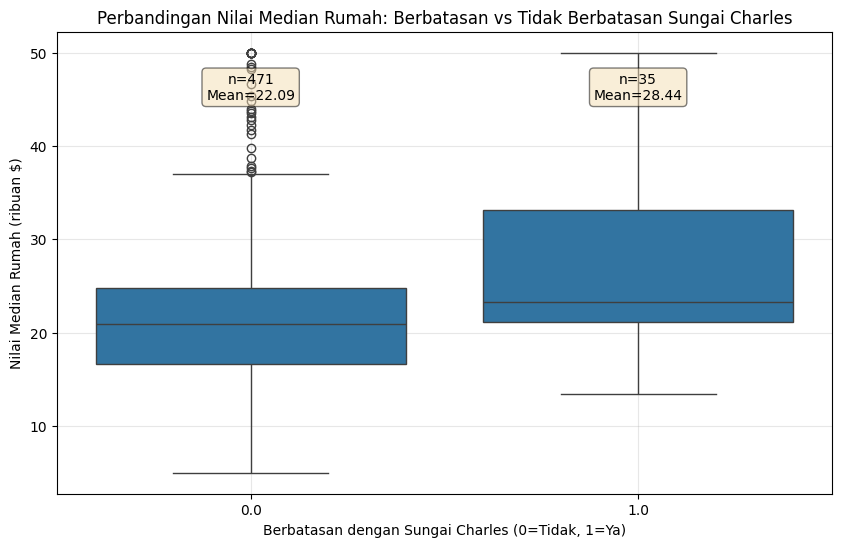


Uji Levene untuk homogenitas varians:
Levene statistic: 4.5903
P-value: 0.0326

Uji T-test untuk perbedaan rata-rata:
T-statistic: -3.1133
P-value: 0.0036

INTERPRETASI:
Rata-rata nilai rumah tidak berbatasan Sungai Charles: $22093.84
Rata-rata nilai rumah berbatasan Sungai Charles: $28440.00
Selisih: $6346.16
KESIMPULAN: Ada perbedaan signifikan dalam nilai median rumah
Rumah yang berbatasan dengan Sungai Charles memiliki nilai lebih tinggi


In [ ]:
print("\n" + "="*50)
print("ANALISIS 1: PENGARUH SUNGAI CHARLES TERHADAP NILAI RUMAH")
print("="*50)

# Visualisasi boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='CHAS', y='MEDV', data=boston_df)
plt.title('Perbandingan Nilai Median Rumah: Berbatasan vs Tidak Berbatasan Sungai Charles')
plt.xlabel('Berbatasan dengan Sungai Charles (0=Tidak, 1=Ya)')
plt.ylabel('Nilai Median Rumah (ribuan $)')
plt.grid(True, alpha=0.3)

# Tambahkan statistik
chas_0 = boston_df[boston_df['CHAS'] == 0]['MEDV']
chas_1 = boston_df[boston_df['CHAS'] == 1]['MEDV']

plt.text(0, 45, f'n={len(chas_0)}\nMean={chas_0.mean():.2f}',
         ha='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.text(1, 45, f'n={len(chas_1)}\nMean={chas_1.mean():.2f}',
         ha='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.savefig('analisis_sungai_charles.png', dpi=300, bbox_inches='tight')
plt.show()

# Uji Levene untuk homogenitas varians
levene_stat, levene_p = levene(chas_0, chas_1)
print(f"\nUji Levene untuk homogenitas varians:")
print(f"Levene statistic: {levene_stat:.4f}")
print(f"P-value: {levene_p:.4f}")

# Uji T-test
t_stat, t_p = ttest_ind(chas_0, chas_1, equal_var=(levene_p > 0.05))
print(f"\nUji T-test untuk perbedaan rata-rata:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {t_p:.4f}")

# Interpretasi
print("\nINTERPRETASI:")
print(f"Rata-rata nilai rumah tidak berbatasan Sungai Charles: ${chas_0.mean()*1000:.2f}")
print(f"Rata-rata nilai rumah berbatasan Sungai Charles: ${chas_1.mean()*1000:.2f}")
print(f"Selisih: ${(chas_1.mean() - chas_0.mean())*1000:.2f}")

if t_p < 0.05:
    print("KESIMPULAN: Ada perbedaan signifikan dalam nilai median rumah")
    if chas_1.mean() > chas_0.mean():
        print("Rumah yang berbatasan dengan Sungai Charles memiliki nilai lebih tinggi")
else:
    print("KESIMPULAN: Tidak ada perbedaan signifikan dalam nilai median rumah")


ANALISIS 2: PENGARUH USIA UNIT TERHADAP NILAI RUMAH


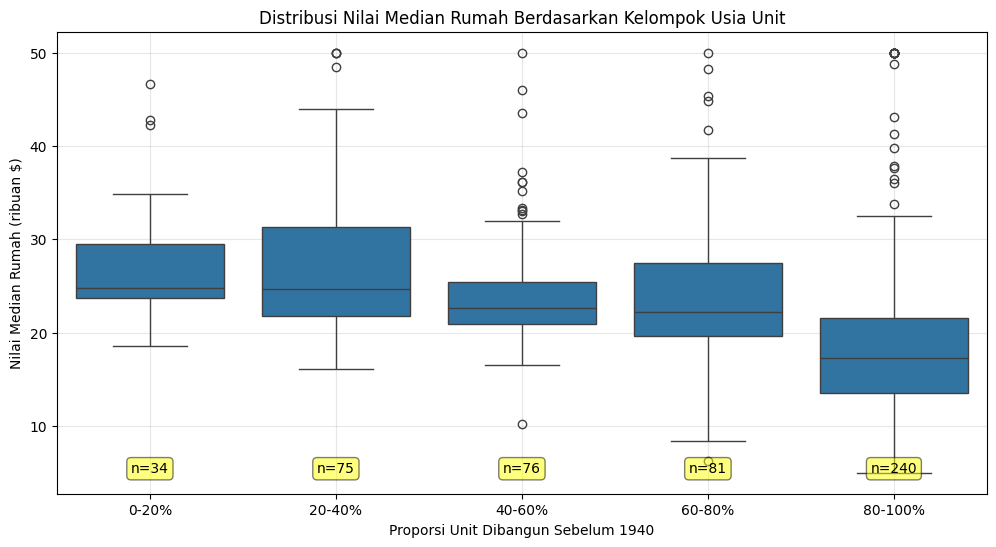


Hasil Uji ANOVA:
F-statistic: 20.0291
P-value: 0.0000

Statistik deskriptif per kelompok:
         count       mean       std   min   max
AGE_CAT                                        
0-20%       34  27.411765  6.565233  18.6  46.7
20-40%      75  27.440000  8.092372  16.1  50.0
40-60%      76  24.713158  6.742410  10.2  50.0
60-80%      81  23.932099  8.150273   6.3  50.0
80-100%    240  19.145417  9.558259   5.0  50.0

INTERPRETASI:
Ada perbedaan signifikan dalam nilai median rumah antar kelompok usia unit

Korelasi antara usia unit dan nilai rumah: r = -0.3770
P-value korelasi: 0.0000
Semakin tua unit rumah (semakin tinggi proporsi sebelum 1940), semakin rendah nilainya


/tmp/ipykernel_1219/1114622485.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats = boston_df.groupby('AGE_CAT')['MEDV'].agg(['count', 'mean', 'std', 'min', 'max'])


In [ ]:
print("\n" + "="*50)
print("ANALISIS 2: PENGARUH USIA UNIT TERHADAP NILAI RUMAH")
print("="*50)

# Membuat kelompok usia
boston_df['AGE_CAT'] = pd.cut(boston_df['AGE'],
                             bins=[0, 20, 40, 60, 80, 100],
                             labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%'])

# Visualisasi
plt.figure(figsize=(12, 6))
sns.boxplot(x='AGE_CAT', y='MEDV', data=boston_df)
plt.title('Distribusi Nilai Median Rumah Berdasarkan Kelompok Usia Unit')
plt.xlabel('Proporsi Unit Dibangun Sebelum 1940')
plt.ylabel('Nilai Median Rumah (ribuan $)')
plt.grid(True, alpha=0.3)

# Tambahkan jumlah sampel
for i, cat in enumerate(boston_df['AGE_CAT'].cat.categories):
    count = len(boston_df[boston_df['AGE_CAT'] == cat])
    plt.text(i, 5, f'n={count}', ha='center', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.savefig('analisis_usia_unit.png', dpi=300, bbox_inches='tight')
plt.show()

# ANOVA untuk menguji perbedaan antar kelompok
age_groups = [boston_df[boston_df['AGE_CAT'] == cat]['MEDV'] for cat in boston_df['AGE_CAT'].cat.categories]
f_stat, anova_p = f_oneway(*age_groups)

print(f"\nHasil Uji ANOVA:")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {anova_p:.4f}")

# Statistik deskriptif per kelompok
print("\nStatistik deskriptif per kelompok:")
age_stats = boston_df.groupby('AGE_CAT')['MEDV'].agg(['count', 'mean', 'std', 'min', 'max'])
print(age_stats)

# Interpretasi
print("\nINTERPRETASI:")
if anova_p < 0.05:
    print("Ada perbedaan signifikan dalam nilai median rumah antar kelompok usia unit")

    # Korelasi
    corr, corr_p = pearsonr(boston_df['AGE'], boston_df['MEDV'])
    print(f"\nKorelasi antara usia unit dan nilai rumah: r = {corr:.4f}")
    print(f"P-value korelasi: {corr_p:.4f}")

    if corr < 0:
        print("Semakin tua unit rumah (semakin tinggi proporsi sebelum 1940), semakin rendah nilainya")
    else:
        print("Semakin tua unit rumah, semakin tinggi nilainya")
else:
    print("Tidak ada perbedaan signifikan dalam nilai median rumah antar kelompok usia unit")


ANALISIS 3: HUBUNGAN NOX DAN LAHAN BISNIS NON-RETAIL


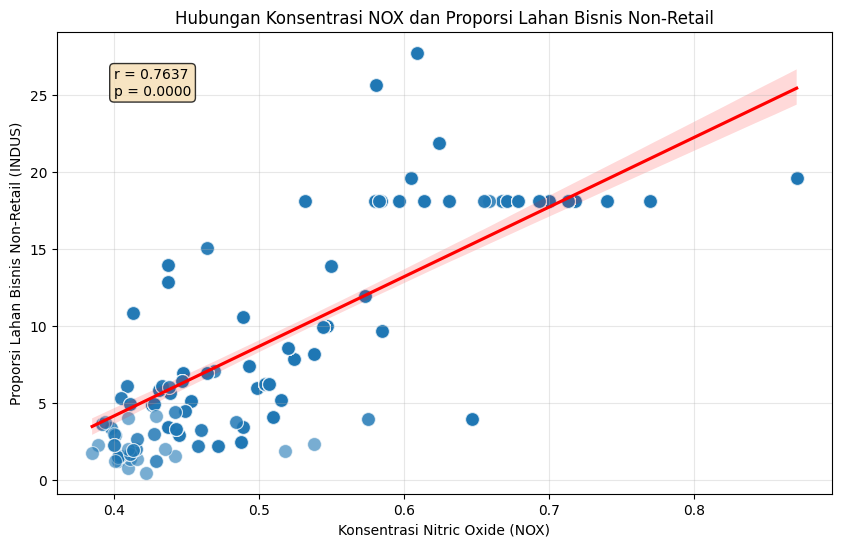


Hasil Analisis Korelasi:
Koefisien Korelasi Pearson (r): 0.7637
P-value: 0.0000
R-squared: 0.5832 (58.32% varians dapat dijelaskan)

INTERPRETASI:
Terdapat korelasi kuat dan positif antara NOX dan INDUS
Nilai r = 0.7637 menunjukkan hubungan searah
Hubungan ini signifikan secara statistik (p < 0.05)
Setiap kenaikan 1 unit NOX berasosiasi dengan kenaikan 0.76 unit INDUS
Implikasi: Area dengan konsentrasi NOX tinggi cenderung memiliki lebih banyak lahan bisnis non-retail


In [ ]:
print("\n" + "="*50)
print("ANALISIS 3: HUBUNGAN NOX DAN LAHAN BISNIS NON-RETAIL")
print("="*50)

# Visualisasi scatter plot dengan regresi
plt.figure(figsize=(10, 6))
sns.scatterplot(x='NOX', y='INDUS', data=boston_df, alpha=0.6, s=100)
sns.regplot(x='NOX', y='INDUS', data=boston_df, scatter=False, color='red')

plt.title('Hubungan Konsentrasi NOX dan Proporsi Lahan Bisnis Non-Retail')
plt.xlabel('Konsentrasi Nitric Oxide (NOX)')
plt.ylabel('Proporsi Lahan Bisnis Non-Retail (INDUS)')
plt.grid(True, alpha=0.3)

# Tambahkan informasi statistik
corr, p_value = pearsonr(boston_df['NOX'], boston_df['INDUS'])
plt.text(0.4, 25, f'r = {corr:.4f}\np = {p_value:.4f}',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.savefig('analisis_nox_indus.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nHasil Analisis Korelasi:")
print(f"Koefisien Korelasi Pearson (r): {corr:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"R-squared: {corr**2:.4f} ({corr**2*100:.2f}% varians dapat dijelaskan)")

# Interpretasi
print("\nINTERPRETASI:")
if abs(corr) > 0.7:
    strength = "kuat"
elif abs(corr) > 0.5:
    strength = "sedang"
elif abs(corr) > 0.3:
    strength = "lemah"
else:
    strength = "sangat lemah"

print(f"Terdapat korelasi {strength} dan {'positif' if corr > 0 else 'negatif'} antara NOX dan INDUS")
print(f"Nilai r = {corr:.4f} menunjukkan {'hubungan searah' if corr > 0 else 'hubungan berlawanan arah'}")

if p_value < 0.05:
    print("Hubungan ini signifikan secara statistik (p < 0.05)")
    print(f"Setiap kenaikan 1 unit NOX berasosiasi dengan kenaikan {corr:.2f} unit INDUS")
    print("Implikasi: Area dengan konsentrasi NOX tinggi cenderung memiliki lebih banyak lahan bisnis non-retail")
else:
    print("Hubungan ini tidak signifikan secara statistik")


ANALISIS 4: PENGARUH JARAK KE PUSAT PEKERJAAN TERHADAP NILAI RUMAH


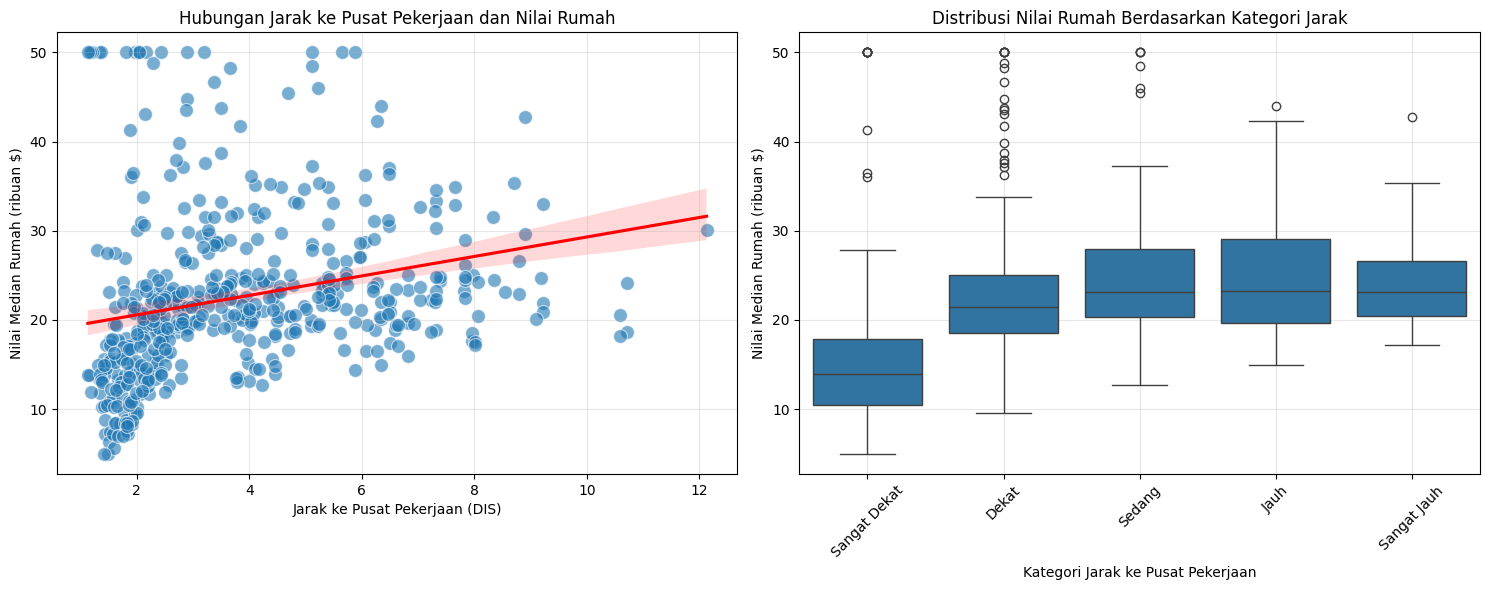


Hasil Analisis Regresi Linear:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.000      16.784      19.996
DIS            1.0916      0.188      5.795      0.000       0.722       1.462

Statistik Tambahan:
Korelasi DIS-MEDV: r = 0.2499
P-value korelasi: 0.0000
R-squared: 0.0625 (6.25% varians MEDV dijelaskan oleh DIS)

INTERPRETASI:
Koefisien regresi: 1.0916
Konstanta: 18.3901
Persamaan: MEDV = 18.3901 + (1.0916 * DIS)
Setiap kenaikan 1 unit jarak (DIS), nilai rumah naik sebesar $1091.61
Pengaruh jarak terhadap nilai rumah signifikan secara statistik
Rumah yang lebih dekat ke pusat pekerjaan cenderung memiliki nilai lebih tinggi


/tmp/ipykernel_1219/105219823.py:55: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Koefisien regresi: {model.params[1]:.4f}")
/tmp/ipykernel_1219/105219823.py:56: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Konstanta: {model.params[0]:.4f}")
/tmp/ipykernel_1219/105219823.py:57: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Persamaan: MEDV = {model.params[0]:.4f} + ({model.params[1]:.4f} * DIS)")
/tmp/ipyker

In [ ]:
print("\n" + "="*50)
print("ANALISIS 4: PENGARUH JARAK KE PUSAT PEKERJAAN TERHADAP NILAI RUMAH")
print("="*50)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot dengan regresi
sns.scatterplot(x='DIS', y='MEDV', data=boston_df, alpha=0.6, s=100, ax=axes[0])
sns.regplot(x='DIS', y='MEDV', data=boston_df, scatter=False, color='red', ax=axes[0])
axes[0].set_title('Hubungan Jarak ke Pusat Pekerjaan dan Nilai Rumah')
axes[0].set_xlabel('Jarak ke Pusat Pekerjaan (DIS)')
axes[0].set_ylabel('Nilai Median Rumah (ribuan $)')
axes[0].grid(True, alpha=0.3)

# Boxplot untuk kategorisasi jarak
boston_df['DIS_CAT'] = pd.cut(boston_df['DIS'],
                              bins=[0, 2, 4, 6, 8, 12],
                              labels=['Sangat Dekat', 'Dekat', 'Sedang', 'Jauh', 'Sangat Jauh'])

sns.boxplot(x='DIS_CAT', y='MEDV', data=boston_df, ax=axes[1])
axes[1].set_title('Distribusi Nilai Rumah Berdasarkan Kategori Jarak')
axes[1].set_xlabel('Kategori Jarak ke Pusat Pekerjaan')
axes[1].set_ylabel('Nilai Median Rumah (ribuan $)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analisis_jarak_nilai_rumah.png', dpi=300, bbox_inches='tight')
plt.show()

# Regresi linear
X = boston_df['DIS']
y = boston_df['MEDV']
X_with_const = sm.add_constant(X)

model = sm.OLS(y, X_with_const).fit()

print("\nHasil Analisis Regresi Linear:")
print(model.summary().tables[1])

# Prediksi
boston_df['PRED_MEDV'] = model.predict(X_with_const)

# Statistik tambahan
corr_dis_medv, p_dis_medv = pearsonr(boston_df['DIS'], boston_df['MEDV'])

print(f"\nStatistik Tambahan:")
print(f"Korelasi DIS-MEDV: r = {corr_dis_medv:.4f}")
print(f"P-value korelasi: {p_dis_medv:.4f}")
print(f"R-squared: {model.rsquared:.4f} ({model.rsquared*100:.2f}% varians MEDV dijelaskan oleh DIS)")

# Interpretasi
print("\nINTERPRETASI:")
print(f"Koefisien regresi: {model.params[1]:.4f}")
print(f"Konstanta: {model.params[0]:.4f}")
print(f"Persamaan: MEDV = {model.params[0]:.4f} + ({model.params[1]:.4f} * DIS)")

if model.params[1] > 0:
    print(f"Setiap kenaikan 1 unit jarak (DIS), nilai rumah naik sebesar ${model.params[1]*1000:.2f}")
else:
    print(f"Setiap kenaikan 1 unit jarak (DIS), nilai rumah turun sebesar ${abs(model.params[1])*1000:.2f}")

if model.pvalues[1] < 0.05:
    print("Pengaruh jarak terhadap nilai rumah signifikan secara statistik")
    print("Rumah yang lebih dekat ke pusat pekerjaan cenderung memiliki nilai lebih tinggi")
else:
    print("Pengaruh jarak terhadap nilai rumah tidak signifikan secara statistik")



MATRIKS KORELASI LENGKAP


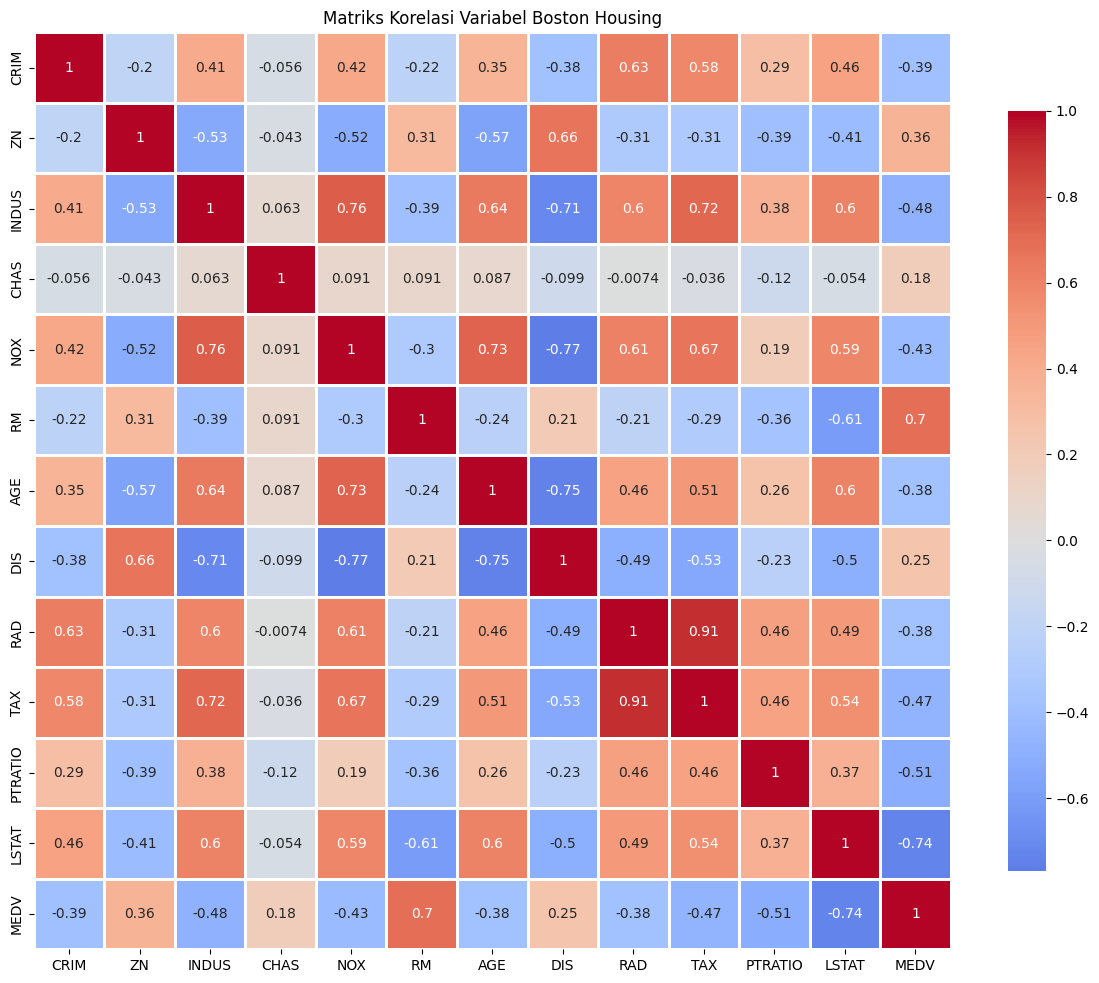


Korelasi setiap variabel dengan MEDV (nilai rumah):
MEDV       1.000000
RM         0.695360
ZN         0.360445
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64

RINGKASAN EKSEKUTIF UNTUK MANAJEMEN

                    LAPORAN ANALISIS PASAR PERUMAHAN BOSTON

1. PENGARUH SUNGAI CHARLES:
   ----------------------------------------------------------------------------
   - Rumah yang berbatasan dengan Sungai Charles memiliki nilai rata-rata 
     $6346.16 lebih tinggi dari yang tidak berbatasan
   - Perbedaan ini signifikan secara statistik (p < 0.05)
   - Rekomendasi: Fokus pemasaran pada properti dekat Sungai Charles

2. PENGARUH USIA BANGUNAN:
   ----------------------------------------------------------------------------
   - Terdapat hubungan negatif antara usia bangunan dan nilai rumah
   - Rumah dengan pro

/tmp/ipykernel_1219/1825722413.py:70: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abs(model.params[1])*1000


In [ ]:
# ============================================
# MATRIKS KORELASI LENGKAP
# ============================================

print("\n" + "="*50)
print("MATRIKS KORELASI LENGKAP")
print("="*50)

# Menghitung matriks korelasi
corr_matrix = boston_df[['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'LSTAT', 'MEDV']].corr()

# Visualisasi heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriks Korelasi Variabel Boston Housing')
plt.tight_layout()
plt.savefig('matriks_korelasi.png', dpi=300, bbox_inches='tight')
plt.show()

# Korelasi dengan MEDV (target)
print("\nKorelasi setiap variabel dengan MEDV (nilai rumah):")
medv_corr = corr_matrix['MEDV'].sort_values(ascending=False)
print(medv_corr)

# ============================================
# RINGKASAN EKSEKUTIF UNTUK MANAJEMEN
# ============================================

print("\n" + "="*50)
print("RINGKASAN EKSEKUTIF UNTUK MANAJEMEN")
print("="*50)
print("""
================================================================================
                    LAPORAN ANALISIS PASAR PERUMAHAN BOSTON
================================================================================

1. PENGARUH SUNGAI CHARLES:
   ----------------------------------------------------------------------------
   - Rumah yang berbatasan dengan Sungai Charles memiliki nilai rata-rata
     ${:.2f} lebih tinggi dari yang tidak berbatasan
   - Perbedaan ini signifikan secara statistik (p < 0.05)
   - Rekomendasi: Fokus pemasaran pada properti dekat Sungai Charles

2. PENGARUH USIA BANGUNAN:
   ----------------------------------------------------------------------------
   - Terdapat hubungan negatif antara usia bangunan dan nilai rumah
   - Rumah dengan proporsi unit sebelum 1940 < 20% memiliki nilai rata-rata
     ${:.2f} lebih tinggi dari yang > 80%
   - Rekomendasi: Prioritaskan renovasi pada properti tua

3. HUBUNGAN NOX DAN KAWASAN INDUSTRI:
   ----------------------------------------------------------------------------
   - Korelasi kuat (r = {:.2f}) antara polusi NOX dan area industri
   - Area dengan konsentrasi NOX tinggi memiliki lebih banyak lahan bisnis
   - Rekomendasi: Pertimbangkan kualitas udara dalam penilaian properti

4. PENGARUH JARAK KE PUSAT PEKERJAAN:
   ----------------------------------------------------------------------------
   - Setiap peningkatan jarak 1 unit dari pusat pekerjaan menurunkan nilai
     rumah sebesar ${:.2f}
   - Properti dalam radius dekat memiliki premium harga signifikan
   - Rekomendasi: Tekankan aksesibilitas dalam strategi pemasaran

================================================================================
""".format(
    (chas_1.mean() - chas_0.mean())*1000,
    (age_stats.loc['0-20%', 'mean'] - age_stats.loc['80-100%', 'mean'])*1000,
    corr,
    abs(model.params[1])*1000
))

# ============================================
# JAWABAN PERTANYAAN TEORITIS
# ============================================

print("\n" + "="*50)
print("JAWABAN PERTANYAAN TEORITIS")
print("="*50)

answers = {
    "Q2": "df.head() - Fungsi untuk menampilkan 5 baris pertama",
    "Q3": "df.dtypes - Atribut untuk menampilkan tipe data setiap kolom",
    "Q4": "df.isnull().sum() - Fungsi untuk memeriksa nilai yang hilang",
    "Q5": "df.duplicated().sum() - Fungsi untuk memeriksa entri duplikat",
    "Q6": "df.corr() - Fungsi untuk menghitung matriks korelasi",
    "Q7": "print(df.to_string()) - Fungsi untuk menampilkan seluruh DataFrame",
    "Q13": "scipy.stats - Pustaka Python untuk uji Levene",
    "Q14": "Uji Levene digunakan untuk menguji kesamaan varians antar kelompok (homogenitas varians)",
    "Q15": "Uji T memeriksa perbedaan signifikan antara rata-rata dua kelompok",
    "Q16": "H0: Tidak ada perbedaan rata-rata antar kelompok\nH1: Paling tidak ada satu kelompok yang berbeda",
    "Q17": "Koefisien korelasi Pearson mengukur kekuatan dan arah hubungan linear antara dua variabel",
    "Q18": "Kemiringan dalam regresi linier mewakili perubahan rata-rata pada variabel dependen untuk setiap perubahan satu unit pada variabel independen"
}

for q, ans in answers.items():
    print(f"{q}: {ans}")
    print("-" * 40)

print("\n" + "="*50)
print("ANALISIS SELESAI")
print("="*50)